<a href="https://colab.research.google.com/github/adwaiti-04/Compititive-Coding/blob/main/Airplane_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

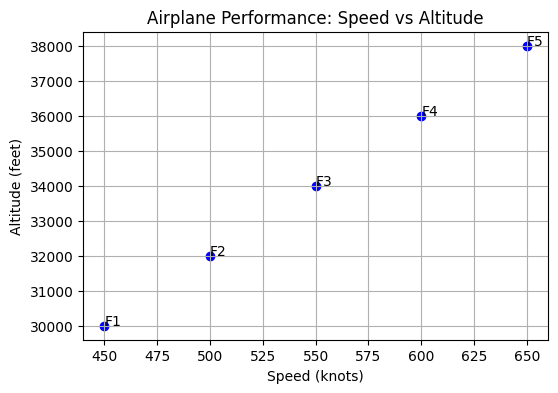

AttributeError: The geopandas.dataset has been deprecated and was removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# -----------------------------
# Scatter Plot: Speed vs Altitude
# -----------------------------
# Sample dataset
data = {
    "Flight": ["F1", "F2", "F3", "F4", "F5"],
    "Speed": [450, 500, 550, 600, 650],   # in knots
    "Altitude": [30000, 32000, 34000, 36000, 38000]  # in feet
}
df = pd.DataFrame(data)

# Create scatter plot
plt.figure(figsize=(6, 4))
plt.scatter(df["Speed"], df["Altitude"], color="blue", marker="o")
for i, txt in enumerate(df["Flight"]):
    plt.annotate(txt, (df["Speed"][i], df["Altitude"][i]))
plt.title("Airplane Performance: Speed vs Altitude")
plt.xlabel("Speed (knots)")
plt.ylabel("Altitude (feet)")
plt.grid(True)
plt.show()

# -----------------------------
# Geospatial Map: Flight Routes
# -----------------------------
# Sample coordinates (latitude, longitude)
coords = {
    "Flight": ["F1", "F2", "F3"],
    "Latitude": [19.0760, 28.7041, 12.9716],   # Mumbai, Delhi, Bangalore
    "Longitude": [72.8777, 77.1025, 77.5946]
}
df_geo = pd.DataFrame(coords)

# Convert to GeoDataFrame
geometry = [Point(xy) for xy in zip(df_geo["Longitude"], df_geo["Latitude"])]
gdf = gpd.GeoDataFrame(df_geo, geometry=geometry)

# Load world map
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

# Plot map with flight points
fig, ax = plt.subplots(figsize=(8, 6))
world.plot(ax=ax, color="lightgray")
gdf.plot(ax=ax, color="red", markersize=100)

for x, y, label in zip(df_geo["Longitude"], df_geo["Latitude"], df_geo["Flight"]):
    plt.text(x+0.5, y+0.5, label, fontsize=9)

plt.title("Airplane Project: Flight Routes")
plt.show()

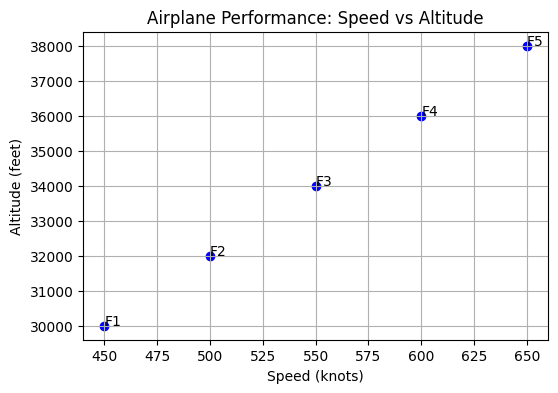

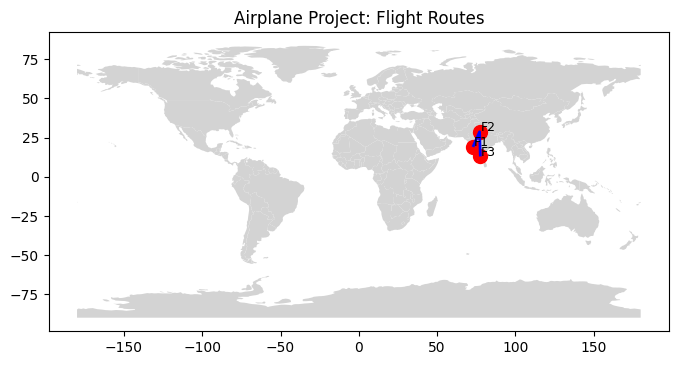

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, LineString

# -----------------------------
# Scatter Plot: Speed vs Altitude
# -----------------------------
# Sample dataset
data = {
    "Flight": ["F1", "F2", "F3", "F4", "F5"],
    "Speed": [450, 500, 550, 600, 650],   # in knots
    "Altitude": [30000, 32000, 34000, 36000, 38000]  # in feet
}
df = pd.DataFrame(data)

# Create scatter plot
plt.figure(figsize=(6, 4))
plt.scatter(df["Speed"], df["Altitude"], color="blue", marker="o")
for i, txt in enumerate(df["Flight"]):
    plt.annotate(txt, (df["Speed"][i], df["Altitude"][i]))
plt.title("Airplane Performance: Speed vs Altitude")
plt.xlabel("Speed (knots)")
plt.ylabel("Altitude (feet)")
plt.grid(True)
plt.show()

# -----------------------------
# Geospatial Map: Flight Routes
# -----------------------------
# Sample coordinates (latitude, longitude)
coords = {
    "Flight": ["F1", "F2", "F3"],
    "Latitude": [19.0760, 28.7041, 12.9716],   # Mumbai, Delhi, Bangalore
    "Longitude": [72.8777, 77.1025, 77.5946]
}
df_geo = pd.DataFrame(coords)

# Convert to GeoDataFrame
geometry = [Point(xy) for xy in zip(df_geo["Longitude"], df_geo["Latitude"])]
gdf = gpd.GeoDataFrame(df_geo, geometry=geometry)

# Load world map from Natural Earth (latest GeoPandas-compatible method)
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

# Create flight path line (connecting points in order)
flight_path = LineString(list(zip(df_geo["Longitude"], df_geo["Latitude"])))
flight_gdf = gpd.GeoDataFrame(geometry=[flight_path])

# Plot map with flight points and connecting line
fig, ax = plt.subplots(figsize=(8, 6))
world.plot(ax=ax, color="lightgray")
gdf.plot(ax=ax, color="red", markersize=100)
flight_gdf.plot(ax=ax, color="blue", linewidth=2)

# Add labels
for x, y, label in zip(df_geo["Longitude"], df_geo["Latitude"], df_geo["Flight"]):
    plt.text(x+0.5, y+0.5, label, fontsize=9)

plt.title("Airplane Project: Flight Routes")
plt.show()

